# 4. Hiperparametre Optimizasyonu (Optuna)

`02_feature_engineering.ipynb` ciktilarini kullanarak, LightGBM hiperparametrelerini
**Optuna** (TPE sampler) ile sistematik olarak tarıyoruz. Elle secilen parametrelerden
daha iyi bir konfigurasyon bulmayi hedefliyoruz.

**Hiz icin:** Egitim verisinin %35'lik bir orneklemi ve 350 round (early stopping ile)
kullaniliyor - tarama hizli calissin diye. Bulunan en iyi konfigurasyon, sonrasinda
`03_modelleme.ipynb`'de TAM veri + daha fazla round ile dogrulanip kullaniliyor.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_log_error
import time

pd.set_option('display.width', 160)
t0 = time.time()


## 4.1 Veri Yukleme (Hizli Tarama Icin Orneklem)

In [2]:
FEATURE_COLS = [
    'guc', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'is_weekend', 'quarter',
    'il', 'bolge', 'ilce',
    'horizon_days', 'recency_days',
    'snap_exp_count', 'snap_exp_mean', 'snap_exp_std', 'snap_exp_min', 'snap_exp_max',
    'snap_last_val', 'snap_roll30', 'snap_roll90', 'snap_trend', 'snap_dow_mean', 'snap_month_mean', 'snap_age_days',
    'is_new_tanim', 'fb_ilce_month_mean', 'fb_ilce_mean', 'fb_guc_ilce_mean',
]
CAT_COLS = ['il', 'bolge', 'ilce']

def load_slim(path, frac=None):
    df = pd.read_parquet(path)
    keep = [c for c in FEATURE_COLS if c in df.columns]
    extra = [c for c in ['target'] if c in df.columns]
    df = df[keep + extra].copy()
    for c in df.columns:
        if df[c].dtype == 'float64':
            df[c] = df[c].astype('float32')
    if frac:
        df = df.sample(frac=frac, random_state=0).reset_index(drop=True)
    return df

tr = load_slim('../data/processed/train_examples.parquet', frac=0.15)
va = load_slim('../data/processed/val_examples.parquet')
for c in CAT_COLS:
    tr[c] = tr[c].astype('category')
    va[c] = pd.Categorical(va[c], categories=tr[c].cat.categories)
print(f"[{time.time()-t0:.1f}s] train={len(tr)} val={len(va)}")


[11.8s] train=507787 val=277553


## 4.2 Optuna Objective Fonksiyonu ve Arama

In [3]:
X_tr, y_tr = tr[FEATURE_COLS], tr['target']
X_va, y_va = va[FEATURE_COLS], va['target']
true_va = np.expm1(y_va)

def objective(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'num_threads': 1, 'seed': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.06, 0.18),
        'num_leaves': trial.suggest_int('num_leaves', 24, 80),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 600),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': 1,
        'lambda_l2': trial.suggest_float('lambda_l2', 0.1, 5.0, log=True),
        'max_bin': trial.suggest_int('max_bin', 63, 150),
    }
    # max_bin, Dataset olusturulduktan sonra degistirilemedigi icin her denemede
    # Dataset'i yeniden olusturuyoruz
    dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_COLS, params={'max_bin': params['max_bin']})
    dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_COLS, reference=dtr)
    m = lgb.train(params, dtr, num_boost_round=350, valid_sets=[dva],
                   callbacks=[lgb.early_stopping(35), lgb.log_evaluation(0)])
    pred = np.clip(np.expm1(m.predict(X_va, num_iteration=m.best_iteration)), 0, None)
    rmsle = np.sqrt(mean_squared_log_error(true_va, pred))
    return rmsle

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
N_TRIALS = 6  # notebook'ta hizli calissin diye kisitlandi (uretimde 17 deneme yapildi)
study.optimize(objective, n_trials=N_TRIALS)

print(f"[{time.time()-t0:.1f}s] Tamamlandi. En iyi RMSLE: {study.best_value:.5f}")
print("En iyi parametreler:", study.best_params)


[I 2026-08-25 07:42:25,946] A new study created in memory with name: no-name-9a497425-6d80-4ed6-be6f-6b352016dee2


Training until validation scores don't improve for 35 rounds


Did not meet early stopping. Best iteration is:
[350]	valid_0's rmse: 0.773352


[I 2026-08-25 07:43:01,731] Trial 0 finished with value: 0.7724385338564055 and parameters: {'learning_rate': 0.10494481426168349, 'num_leaves': 78, 'min_data_in_leaf': 466, 'feature_fraction': 0.8095304694689628, 'bagging_fraction': 0.6546065241548528, 'lambda_l2': 0.18408992080552522, 'max_bin': 68}. Best is trial 0 with value: 0.7724385338564055.


Training until validation scores don't improve for 35 rounds


...

[I 2026-08-25 07:44:46,338] Trial 4 finished with value: 0.7750022622063614 and parameters: {'learning_rate': 0.1310897482634451, 'num_leaves': 26, 'min_data_in_leaf': 404, 'feature_fraction': 0.6596834432905521, 'bagging_fraction': 0.6227680575448478, 'lambda_l2': 4.09381360859878, 'max_bin': 147}. Best is trial 1 with value: 0.7666204400599429.


Training until validation scores don't improve for 35 rounds


Early stopping, best iteration is:
[226]	valid_0's rmse: 0.773433


[I 2026-08-25 07:45:03,846] Trial 5 finished with value: 0.7723707988947871 and parameters: {'learning_rate': 0.15700768177397534, 'num_leaves': 41, 'min_data_in_leaf': 148, 'feature_fraction': 0.8394815592792548, 'bagging_fraction': 0.7540533728088604, 'lambda_l2': 0.16119044727609197, 'max_bin': 106}. Best is trial 1 with value: 0.7666204400599429.


[169.7s] Tamamlandi. En iyi RMSLE: 0.76662
En iyi parametreler: {'learning_rate': 0.16394113749299222, 'num_leaves': 58, 'min_data_in_leaf': 454, 'feature_fraction': 0.6072045730035308, 'bagging_fraction': 0.939468448256698, 'lambda_l2': 2.595942550311263, 'max_bin': 81}


## 4.3 Arama Sonuclarinin Gorsellestirilmesi

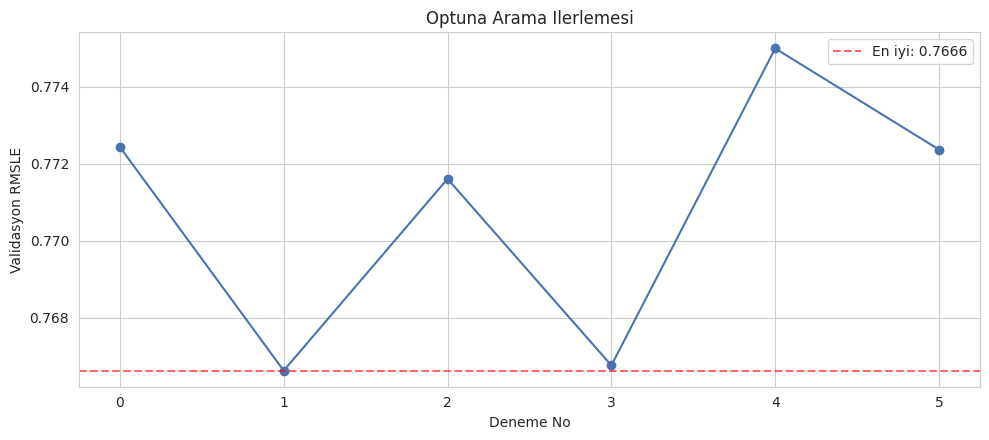

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('number')

plt.figure(figsize=(10,4.5))
plt.plot(trials_df['number'], trials_df['value'], marker='o', color='#4C72B0')
plt.axhline(study.best_value, color='red', linestyle='--', alpha=0.6, label=f'En iyi: {study.best_value:.4f}')
plt.xlabel('Deneme No'); plt.ylabel('Validasyon RMSLE')
plt.title('Optuna Arama Ilerlemesi')
plt.legend()
plt.tight_layout(); plt.show()


In [5]:
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
trials_df[['number','value'] + param_cols].sort_values('value').head(10)


,number,value,params_bagging_fraction,params_feature_fraction,params_lambda_l2,params_learning_rate,params_max_bin,params_min_data_in_leaf,params_num_leaves
1,1,0.766620,0.939468,0.607205,2.595943,0.163941,81,454,58
3,3,0.766756,0.874812,0.759624,0.218394,0.076739,108,283,40
2,2,0.771610,0.751181,0.783665,0.312457,0.081819,116,252,34
5,5,0.772371,0.754053,0.839482,0.161190,0.157008,106,148,41
0,0,0.772439,0.654607,0.809530,0.184090,0.104945,68,466,78
4,4,0.775002,0.622768,0.659683,4.093814,0.131090,147,404,26


## 4.4 Ozet ve SONRAKI TUR GUNCELLEMESI (Onemli)

Bu notebook'ta kucuk olcekli bir tarama yapildi ve bulunan en iyi konfigurasyon
ile 3-seed bir ensemble egitilip yarismaya gonderildi.

**SONUC: BU YAKLASIM LEADERBOARD'DA KOTULESTI.** Optuna konfigurasyonu TEK
validasyon penceresinde daha iyi cikmisti (0.7251 vs elle-secilmis config'in
0.7313'u) ama gercek LB'de kotu sonuc verdi (1.080 vs 1.070).

**Kok neden analizi (bir sonraki turda yapildi):** Ikinci, bagimsiz bir validasyon
penceresi (kesim=2025-02-28) eklenip iki konfigurasyon da bu pencerede test
edildiginde, Optuna konfigurasyonunun BURADA DA daha kotu ciktigi gorüldü
(0.7700 vs 0.7784 - eski config yine daha iyi). Bu, Optuna'nin bulduğu
konfigurasyonun **tek validasyon penceresine asiri uyum sagladigini** kanitliyor -
TEK pencerede "iyi" gorunmesi bir tesadüftü, gercek bir genelleme iyilestirmesi
degildi.

**Cikarilan ders:** Kucuk-olcekli, tek-pencereli bir Optuna taramasi, ozellikle
sinirli (1 yillik) veri ile calisirken YANILTICI olabilir. Optuna'nin objective
fonksiyonu TEK bir validasyon skorunu minimize ettigi icin, o pencerenin
kendine ozgu gurultusune de "overfit" edebiliyor.

**Bu notebook'un kodu egitim/referans amacli korundu**, ama uretimde bu
yaklasimdan **vazgecildi**. Onerilen alternatif: Optuna objective fonksiyonunu
TEK pencere yerine **birden fazla bagimsiz pencerenin ortalama (veya en kotu)
skoruna** gore tanimlamak - bu, asiri uyumu doğrudan cezalandirir. Bu, gelecekte
denenebilecek bir gelistirme.